In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Задача 3

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error as mse

data, target = load_diabetes(return_X_y=True)
a = 1e-6
alpha_linspace = np.linspace(a, 4, 1000)
lm = Lasso(a)
lm.fit(data, target)
values = lm.coef_

<BarContainer object of 10 artists>

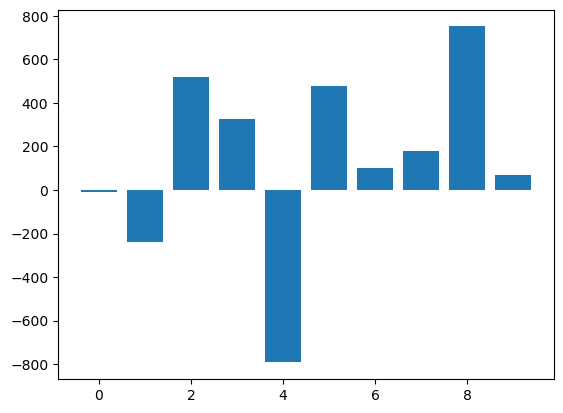

In [3]:
plt.bar(np.arange(values.shape[0]), values)

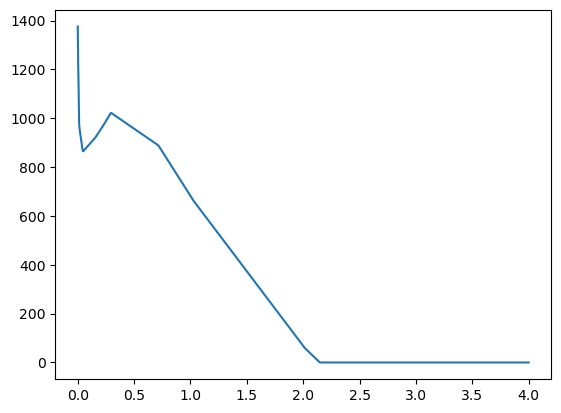

In [4]:
weights_sum = []
for a in alpha_linspace:
    lm = Lasso(a)
    lm.fit(data, target)
    values = lm.coef_
    weights_sum.append(values.sum())
plt.plot(alpha_linspace, weights_sum)

## Задача 4

In [5]:
# Подготовим функцию

def func(x):
    return 8*np.sin(x) * x 

In [6]:
from sklearn.preprocessing import PolynomialFeatures as PF
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

deg = 50

poly = PF(deg)
data = poly.fit_transform(x.reshape(-1, 1))

scaler = StandardScaler()
data = scaler.fit_transform(data)
print(data.shape)

mu = 0
#lm = LinearRegression()
lm = Lasso(mu)
lm.fit(data, y)
plt.plot(x, lm.predict(data), label='Prediction')
plt.plot(x, original_func, color='orange', label='Original function')
plt.scatter(x, y, color='red', marker='.', label='Data points')
plt.legend()
plt.show()

NameError: name 'x' is not defined

In [ ]:
weights = lm.coef_
plt.bar(np.arange(weights.shape[0]), weights)

In [ ]:
N = 100
noise_std = 2

noise = np.random.randn(N) * noise_std
x = np.linspace(0, 10, N)
y = func(x) + noise
original_func = func(x)
plt.plot(x, original_func)
plt.scatter(x, y, color='red', marker='.')

In [ ]:
def make_L1_regression_grad_descent_iteration(X, y, w, mu, alpha):
    grad = 2 * (X @ w - y) @ X + 2 * mu * np.sign(w)
    w -= alpha * grad
    return w

deg = 10

poly = PF(deg)
data = poly.fit_transform(x.reshape(-1, 1))

X_scaler = StandardScaler().fit(data)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
data = X_scaler.transform(data)
y_transformed = y_scaler.transform(y.reshape(-1, 1)).reshape(-1)
#print(y, X_scaler.scale_, y_scaler.mean_)

w = np.random.randn(data.shape[1])

for i in range(int(1e6)):
    make_L1_regression_grad_descent_iteration(data, y_transformed, w, 1e-2,  1e-3)

print(mse(data @ w, y_transformed))
preds = y_scaler.inverse_transform((data @ w).reshape(-1, 1)).reshape(-1)
#reals = y_scaler.inverse_transform((y).reshape(-1, 1)).reshape(-1)
plt.plot(x, preds, label='Prediction')
plt.plot(x, original_func, color='orange', label='Original function')
plt.scatter(x, y, color='red', marker='.', label='Data points')
plt.legend()
plt.show()

In [ ]:
plt.bar(np.arange(w.shape[0]), w)

In [ ]:
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import KFold
from tqdm.notebook import tqdm

def CrossValidation(X, y, k, params):
    kf = KFold(n_splits=k)
    results = []
    
    for fold in (kf.split(X)):
        X_train, X_test = X[fold[0]], X[fold[1]]
        y_train, y_test = y[fold[0]], y[fold[1]]

        w = np.random.randn(X.shape[1])

        for i in range(int(5 * 1e5)):
            make_L1_regression_grad_descent_iteration(X_train, y_train, w,  params['mu'], params['alpha'])

        results.append(mse(X_test @ w, y_test))

    return results

params = {
    'alpha': np.linspace(1e-4, 1e-3, 5).tolist(),
    'mu': [1e-8, 1e-3, 1e-2, 5 * 1e-2, 1e-1, 1, 2, 3]
}

deg = 10

poly = PF(deg)
data = poly.fit_transform(x.reshape(-1, 1))

X_scaler = StandardScaler().fit(data)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
data = X_scaler.transform(data)
y_transformed = y_scaler.transform(y.reshape(-1, 1)).reshape(-1)


scores = {}
for alpha in tqdm(params['alpha']):
    for mu in params['mu']:
        results = CrossValidation(data, y_transformed, 3, {"alpha": alpha, "mu": mu})
        scores[f'alpha={alpha}, mu={mu}'] = (np.array(results).mean())
    

    

In [ ]:
for key in sorted(scores, key=lambda x: scores[x]):
    print(key, scores[key])

In [ ]:
def make_L1_regression_grad_descent_iteration(X, y, w, mu, alpha):
    grad = 2 * (X @ w - y) @ X + 2 * mu * np.sign(w)
    w -= alpha * grad
    return w

deg = 10

poly = PF(deg)
data = poly.fit_transform(x.reshape(-1, 1))

X_scaler = StandardScaler().fit(data)
y_scaler = StandardScaler().fit(y.reshape(-1, 1))
data = X_scaler.transform(data)
y_transformed = y_scaler.transform(y.reshape(-1, 1)).reshape(-1)
#print(y, X_scaler.scale_, y_scaler.mean_)

w = np.random.randn(data.shape[1])

for i in range(int(1e6)):
    make_L1_regression_grad_descent_iteration(data, y_transformed, w, 1e-1,  1e-4)

print(mse(data @ w, y_transformed))
preds = y_scaler.inverse_transform((data @ w).reshape(-1, 1)).reshape(-1)
#reals = y_scaler.inverse_transform((y).reshape(-1, 1)).reshape(-1)
plt.plot(x, preds, label='Prediction')
plt.plot(x, original_func, color='orange', label='Original function')
plt.scatter(x, y, color='red', marker='.', label='Data points')
plt.legend()
plt.show()